In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Import Successfully")

Import Successfully


In [3]:
src = r"C:\Users\Lenovo\OneDrive\Desktop\family\Animesh\01_Thapar_Student_Residencies.jpg"

print("Upload Successfully")

Upload Successfully


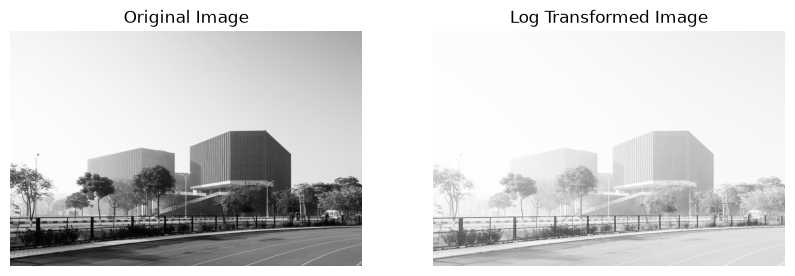

Saved as: log_transformed.jpg


In [8]:
# 1. WAP to enhance the input image using Log transform. Assume c=1. 
img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found!")
else:
    # c = 1
    c = 1

    # Convert image to float
    img_float = img.astype(np.float32)

    # Log transformation
    log_image = c * np.log(1 + img_float)   # c×log(1+r)

    # Normalize to 0-255
    log_image = cv2.normalize(
        log_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Convert to uint8
    log_image = np.uint8(log_image)

    # Display
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(log_image, cmap='gray')
    plt.title("Log Transformed Image")
    plt.axis("off")

    plt.show()

    # Save output
    cv2.imwrite("log_transformed.jpg", log_image)
    print("Saved as: log_transformed.jpg")

Enter the value of gamma:  2


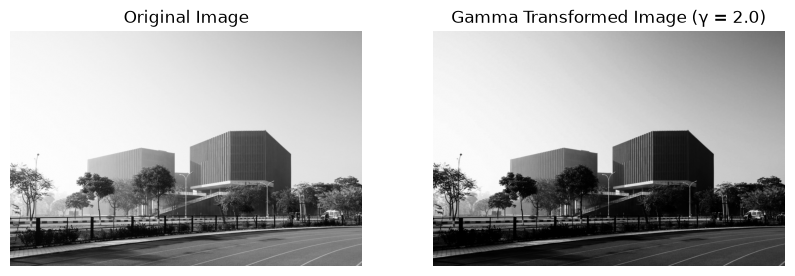

Saved as: gamma_transformed.jpg


In [12]:
# 2. WAP to enhance the input image using Power law/gamma transform. Assume c=1, and input the value of gamma from the user.  
img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found!")
else:
    # Input gamma
    gamma = float(input("Enter the value of gamma: "))

    # c = 1
    c = 1

    # Normalize image to range 0-1
    normalized_img = img / 255.0

    # Power-law transformation
    gamma_image = c * np.power(normalized_img, gamma)  # c×r^γ

    # Convert back to 0-255
    gamma_image = np.uint8(gamma_image * 255)

    # Display
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gamma_image, cmap='gray')
    plt.title(f"Gamma Transformed Image (γ = {gamma})")
    plt.axis("off")

    plt.show()

    # Save output
    cv2.imwrite("gamma_transformed.jpg", gamma_image)
    print("Saved as: gamma_transformed.jpg")

Enter input minimum intensity:  95
Enter input maximum intensity:  110
Enter desired output minimum intensity:  45
Enter desired output maximum intensity:  60


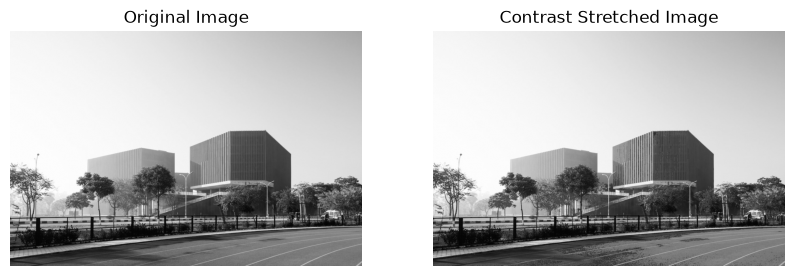

Saved as: contrast_stretched.jpg


In [13]:
# 3. WAP to enhance the input image using Intensity level slicing (Contrast stretching). 
# The input range of intensity values and the desired range of intensity values in the output image are obtained from the user. 
# (Example: The input range of intensity values from 80 to 120 is stretched to 50-150 in the output image)  
img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found!")
else:
    # Input range
    r_min = int(input("Enter input minimum intensity: "))
    r_max = int(input("Enter input maximum intensity: "))

    # Output range
    s_min = int(input("Enter desired output minimum intensity: "))
    s_max = int(input("Enter desired output maximum intensity: "))

    # Create output image
    contrast_image = img.astype(np.float32)

    # Select pixels within input range
    mask = (img >= r_min) & (img <= r_max)

    # Apply contrast stretching
    contrast_image[mask] = (
        s_min +
        ((img[mask] - r_min) * (s_max - s_min)) /
        (r_max - r_min)
    )

    # Clip values to valid range
    contrast_image = np.clip(contrast_image, 0, 255)

    # Convert to uint8
    contrast_image = np.uint8(contrast_image)

    # Display
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(contrast_image, cmap='gray')
    plt.title("Contrast Stretched Image")
    plt.axis("off")

    plt.show()

    # Save output
    cv2.imwrite("contrast_stretched.jpg", contrast_image)
    print("Saved as: contrast_stretched.jpg")